In [1]:
#Import Libraries
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Database
import sqlite3

# Statistics
from scipy.stats import ttest_ind

# Display Settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
#Connect to Database 
conn = sqlite3.connect("coca_cola.db")

print("Database Connected!")

Database Connected!


In [3]:

# Load your CSV file
import os
base_path =os.getcwd()
file_path =os.path.join(base_path ,"KO_CocaCola_Stock_Prices_1980_2026.csv")
df= pd.read_csv(file_path)

# Insert into SQLite
df.to_sql("coca_cola_stock", conn, if_exists="replace", index=False)

print("Table Created and Data Inserted Successfully!")


Table Created and Data Inserted Successfully!


In [4]:
query = "SELECT name FROM sqlite_master WHERE type='table';"
pd.read_sql(query, conn)

,name
0,coca_cola_stock


In [6]:
# Step 1 — Load Data from SQL

df = pd.read_sql("SELECT * FROM coca_cola_stock", conn)

df.head()

,Date,Open,High,Low,Close,Volume,Daily_Return_Pct,Daily_Range,MA_20,MA_50,MA_200,EMA_12,EMA_26,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Width,RSI_14,Volume_MA_20,Cumulative_Return_Pct,Year,Month,Quarter,Day_of_Week
0,1980-01-02,0.1937,0.1944,0.1895,0.1895,3451200,NaN,0.0049,NaN,NaN,NaN,0.1895,0.1895,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,0.00,1980,1,1,Wednesday
1,1980-01-03,0.1895,0.1951,0.1881,0.1944,3960000,2.5858,0.0070,NaN,NaN,NaN,0.1903,0.1899,0.0004,0.0001,NaN,NaN,NaN,NaN,NaN,2.59,1980,1,1,Thursday
2,1980-01-04,0.1944,0.1965,0.1937,0.1965,1694400,1.0802,0.0028,NaN,NaN,NaN,0.1912,0.1904,0.0008,0.0002,NaN,NaN,NaN,NaN,NaN,3.69,1980,1,1,Friday
3,1980-01-07,0.1965,0.1972,0.1951,0.1958,4396800,-0.3562,0.0021,NaN,NaN,NaN,0.1919,0.1908,0.0011,0.0004,NaN,NaN,NaN,NaN,NaN,3.32,1980,1,1,Monday
4,1980-01-08,0.1958,0.1979,0.1958,0.1972,3244800,0.7150,0.0021,NaN,NaN,NaN,0.1927,0.1912,0.0015,0.0006,NaN,NaN,NaN,NaN,NaN,4.06,1980,1,1,Tuesday


In [9]:
#Step 2 — Basic Data 

df.shape

(11615, 25)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11615 entries, 0 to 11614
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   11615 non-null  object 
 1   Open                   11615 non-null  float64
 2   High                   11615 non-null  float64
 3   Low                    11615 non-null  float64
 4   Close                  11615 non-null  float64
 5   Volume                 11615 non-null  int64  
 6   Daily_Return_Pct       11614 non-null  float64
 7   Daily_Range            11615 non-null  float64
 8   MA_20                  11596 non-null  float64
 9   MA_50                  11566 non-null  float64
 10  MA_200                 11416 non-null  float64
 11  EMA_12                 11615 non-null  float64
 12  EMA_26                 11615 non-null  float64
 13  MACD                   11615 non-null  float64
 14  MACD_Signal            11615 non-null  float64
 15  BB

In [11]:
df.describe()

,Open,High,Low,Close,Volume,Daily_Return_Pct,Daily_Range,MA_20,MA_50,MA_200,EMA_12,EMA_26,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Width,RSI_14,Volume_MA_20,Cumulative_Return_Pct,Year,Month,Quarter
count,11615.000000,11615.000000,11615.000000,11615.000000,1.161500e+04,11614.000000,11615.000000,11596.000000,11566.000000,11416.000000,11615.000000,11615.000000,11615.000000,11615.000000,11596.000000,11596.000000,11596.000000,11601.000000,1.159600e+04,11615.000000,11615.000000,11615.000000,11615.000000
mean,18.372081,18.511497,18.228727,18.375667,1.235588e+07,0.062023,0.282770,18.346430,18.302677,18.089756,18.341399,18.298872,0.042527,0.042306,19.027181,17.665679,1.361502,53.629400,1.235579e+07,9596.921738,2002.509858,6.528455,2.509944
std,18.085281,18.203642,17.961267,18.086499,7.498797e+06,1.449943,0.322554,18.020599,17.924832,17.472261,18.045768,17.998355,0.300511,0.280206,18.603002,17.455951,1.611178,16.301113,5.262908e+06,9544.326517,13.302305,3.436180,1.116304
min,0.165100,0.167200,0.162800,0.165100,5.816000e+05,-24.692200,0.000700,0.170300,0.176700,0.191200,0.169200,0.173500,-3.828100,-3.074200,0.178400,0.159000,0.007400,2.150000,2.560800e+06,-12.880000,1980.000000,1.000000,1.000000
25%,3.036850,3.060550,3.009750,3.040100,7.305150e+06,-0.661375,0.055500,3.045300,3.163625,3.468375,3.014800,2.999150,-0.028400,-0.024750,3.189425,2.940925,0.248800,42.250000,8.350300e+06,1504.270000,1991.000000,4.000000,2.000000
50%,13.067400,13.220900,12.935800,13.078500,1.096250e+07,0.013850,0.201200,13.092100,13.103500,13.151800,13.084500,13.086500,0.011900,0.012000,13.700000,12.357150,0.926900,54.000000,1.185182e+07,6801.580000,2002.000000,7.000000,3.000000
75%,28.373900,28.575950,28.235750,28.379700,1.536145e+07,0.748875,0.386600,28.372025,28.665975,27.796900,28.352200,28.316800,0.137200,0.129500,29.295650,27.631600,1.888450,65.290000,1.547808e+07,14876.090000,2014.000000,10.000000,4.000000
max,73.710000,74.900000,73.540000,74.810000,1.241690e+08,19.670400,5.630900,71.117000,70.853800,69.225400,72.557500,71.547400,2.154700,1.942300,75.170300,69.433800,22.096000,98.660000,4.249493e+07,39377.570000,2026.000000,12.000000,4.000000


In [12]:
#Step 3 — Convert Date Column
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df.head()

,Open,High,Low,Close,Volume,Daily_Return_Pct,Daily_Range,MA_20,MA_50,MA_200,EMA_12,EMA_26,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Width,RSI_14,Volume_MA_20,Cumulative_Return_Pct,Year,Month,Quarter,Day_of_Week
Date,,,,,,,,,,,,,,,,,,,,,,,,
1980-01-02,0.1937,0.1944,0.1895,0.1895,3451200,NaN,0.0049,NaN,NaN,NaN,0.1895,0.1895,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,0.00,1980,1,1,Wednesday
1980-01-03,0.1895,0.1951,0.1881,0.1944,3960000,2.5858,0.0070,NaN,NaN,NaN,0.1903,0.1899,0.0004,0.0001,NaN,NaN,NaN,NaN,NaN,2.59,1980,1,1,Thursday
1980-01-04,0.1944,0.1965,0.1937,0.1965,1694400,1.0802,0.0028,NaN,NaN,NaN,0.1912,0.1904,0.0008,0.0002,NaN,NaN,NaN,NaN,NaN,3.69,1980,1,1,Friday
1980-01-07,0.1965,0.1972,0.1951,0.1958,4396800,-0.3562,0.0021,NaN,NaN,NaN,0.1919,0.1908,0.0011,0.0004,NaN,NaN,NaN,NaN,NaN,3.32,1980,1,1,Monday
1980-01-08,0.1958,0.1979,0.1958,0.1972,3244800,0.7150,0.0021,NaN,NaN,NaN,0.1927,0.1912,0.0015,0.0006,NaN,NaN,NaN,NaN,NaN,4.06,1980,1,1,Tuesday


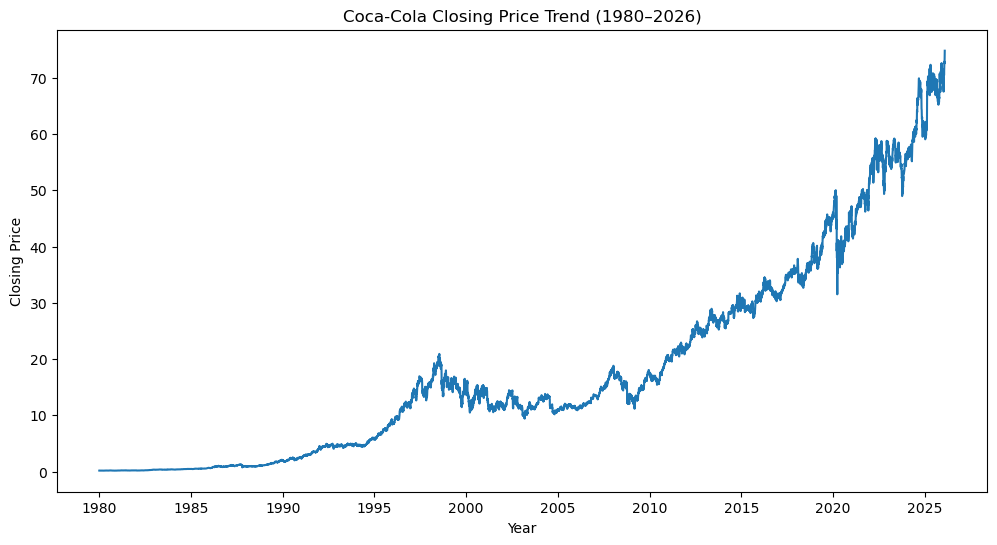

In [13]:
#Closing Price Trend Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("Coca-Cola Closing Price Trend (1980–2026)")
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.show()

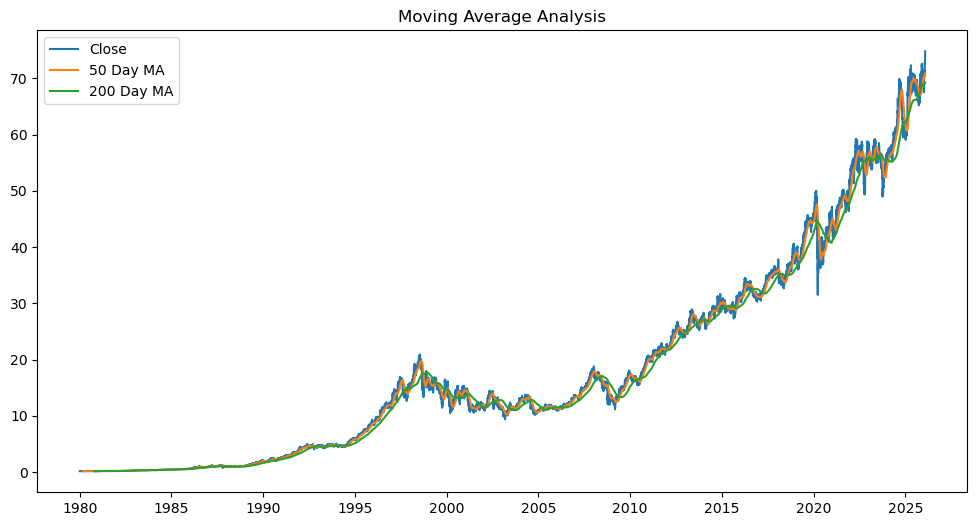

In [14]:
#Moving Average (Trend Analysis)

df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA50'], label='50 Day MA')
plt.plot(df['MA200'], label='200 Day MA')

plt.legend()
plt.title("Moving Average Analysis")
plt.show()

In [15]:
#Calculate Daily Returns
# Calculate Daily Percentage Return
df['Daily_Return'] = df['Close'].pct_change()

df[['Close', 'Daily_Return']].head()

,Close,Daily_Return
Date,,
1980-01-02,0.1895,NaN
1980-01-03,0.1944,0.025858
1980-01-04,0.1965,0.010802
1980-01-07,0.1958,-0.003562
1980-01-08,0.1972,0.007150


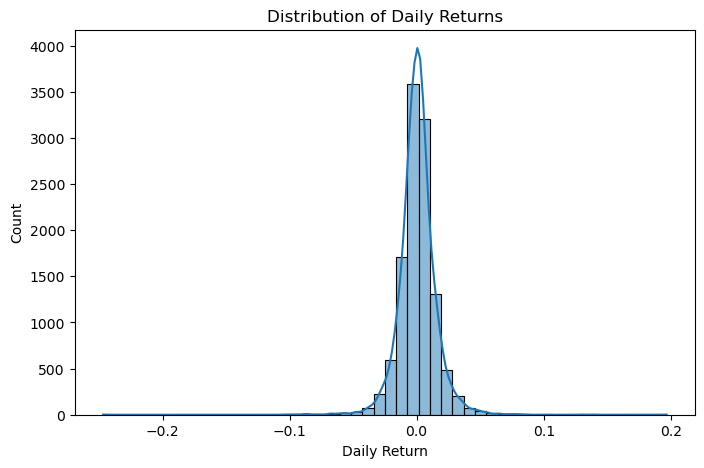

In [16]:
#Plot Daily Return Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['Daily_Return'], bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

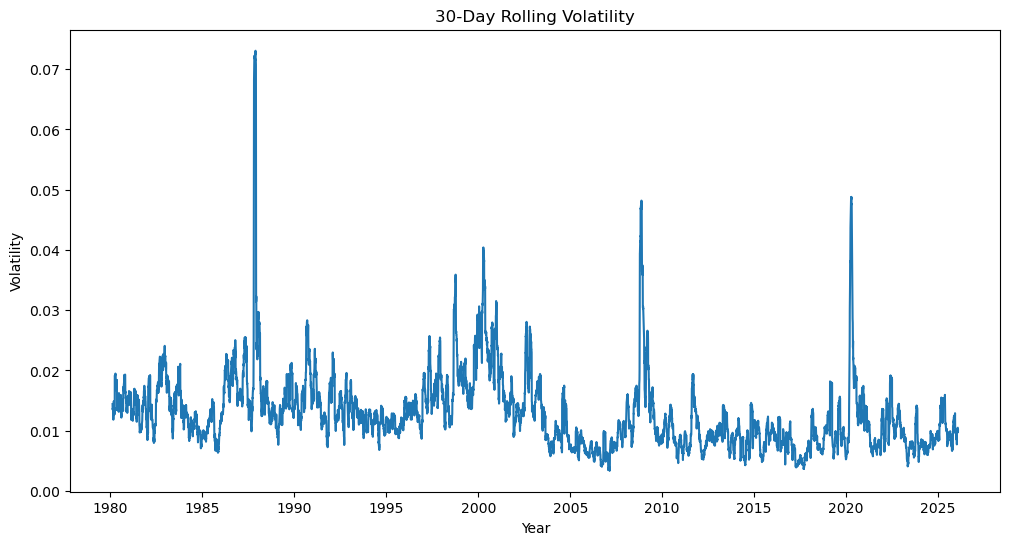

In [17]:
#Rolling Volatility (30-Day)
# 30-day rolling volatility
df['Rolling_Volatility_30'] = df['Daily_Return'].rolling(30).std()

plt.figure(figsize=(12,6))
plt.plot(df['Rolling_Volatility_30'])
plt.title("30-Day Rolling Volatility")
plt.xlabel("Year")
plt.ylabel("Volatility")
plt.show()

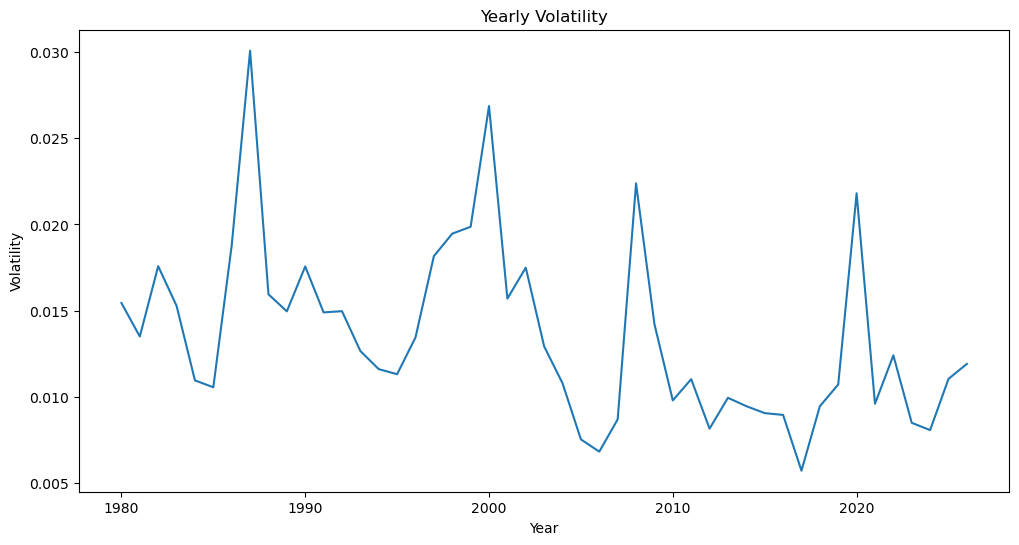

In [18]:
#Yearly Volatility

df['Year'] = df.index.year

yearly_volatility = df.groupby('Year')['Daily_Return'].std()

plt.figure(figsize=(12,6))
yearly_volatility.plot()
plt.title("Yearly Volatility")
plt.xlabel("Year")
plt.ylabel("Volatility")
plt.show()

In [19]:
#Find Most Volatile Year
yearly_volatility.sort_values(ascending=False).head()

Year
1987    0.030090
2000    0.026878
2008    0.022386
2020    0.021810
1999    0.019867
Name: Daily_Return, dtype: float64

In [20]:
# Calculate CAGR(Compound Annual Growth Rate)
start_price = df['Close'].iloc[0]
end_price = df['Close'].iloc[-1]
years = (df.index[-1] - df.index[0]).days / 365

cagr = (end_price / start_price) ** (1 / years) - 1

print("CAGR:", round(cagr * 100, 2), "%")

CAGR: 13.84 %


In [21]:
#Annualized Volatility
annual_volatility = df['Daily_Return'].std() * np.sqrt(252)

print("Annualized Volatility:", round(annual_volatility * 100, 2), "%")

Annualized Volatility: 23.02 %


In [22]:
#Sharpe Ratio
risk_free_rate = 0.02  # assume 2%

annual_return = df['Daily_Return'].mean() * 252

sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

print("Sharpe Ratio:", round(sharpe_ratio, 2))

Sharpe Ratio: 0.59


In [23]:
# Calculate cumulative returns
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod()

# Calculate rolling maximum
rolling_max = df['Cumulative_Return'].cummax()

# Calculate drawdown
df['Drawdown'] = df['Cumulative_Return'] / rolling_max - 1

# Maximum drawdown
max_drawdown = df['Drawdown'].min()

print("Maximum Drawdown:", round(max_drawdown * 100, 2), "%")

Maximum Drawdown: -54.96 %


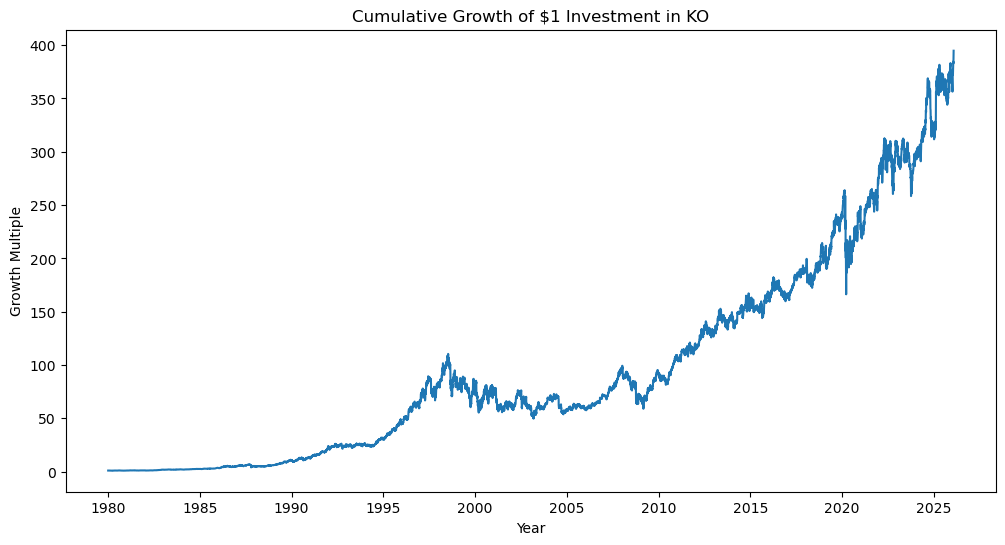

In [27]:
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(df['Cumulative_Return'])
plt.title("Cumulative Growth of $1 Investment in KO")
plt.xlabel("Year")
plt.ylabel("Growth Multiple")
plt.show()

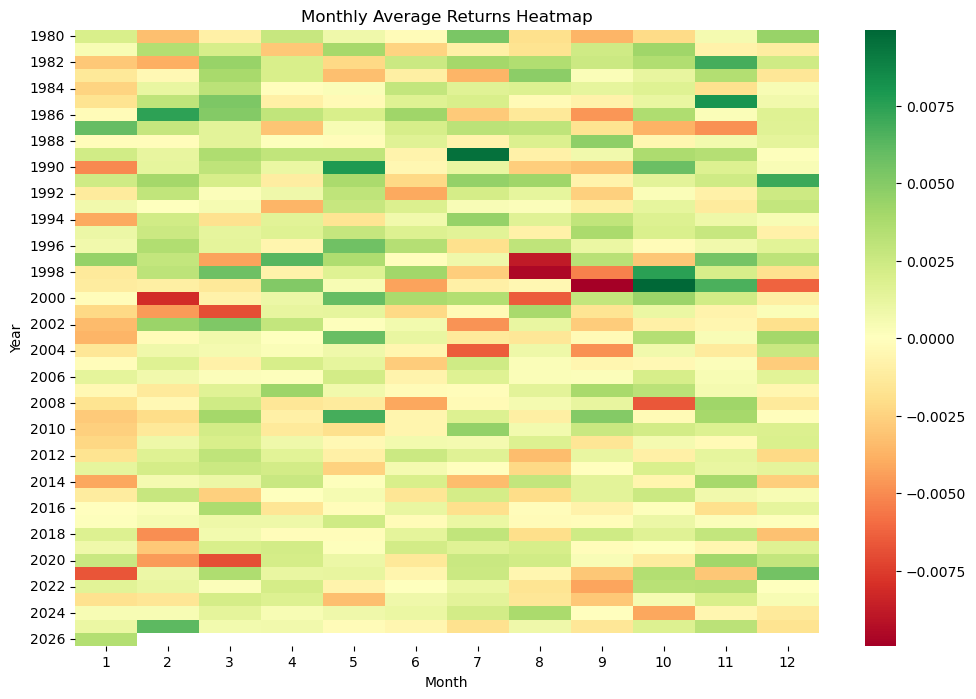

In [28]:
#Heatmap of Monthly Returns

df['Month'] = df.index.month
df['Year'] = df.index.year

monthly_return = df.groupby(['Year', 'Month'])['Daily_Return'].mean().unstack()

plt.figure(figsize=(12,8))
sns.heatmap(monthly_return, cmap='RdYlGn', center=0)
plt.title("Monthly Average Returns Heatmap")
plt.show()

## Advanced Financial Metrics

- CAGR: Measures long-term growth
- Annualized Volatility: Measures yearly risk
- Sharpe Ratio: Risk-adjusted return metric
- Maximum Drawdown: Worst historical loss

In [29]:
#Hypothesis Testing 
from scipy.stats import ttest_ind

# Extract decades
data_1990s = df['1990':'1999']['Close']
data_2010s = df['2010':'2019']['Close']

print("1990s Mean:", data_1990s.mean())
print("2010s Mean:", data_2010s.mean())

1990s Mean: 8.45066625791139
2010s Mean: 29.169123251192367


In [30]:
#Perform T-Test
t_stat, p_value = ttest_ind(data_1990s, data_2010s)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -118.93621828069683
P-Value: 0.0


### Hypothesis Testing Result

H₀ (Null Hypothesis): No difference between 1990s and 2010s average prices  
H₁ (Alternative Hypothesis): Significant difference exists  

If p-value < 0.05 → Reject H₀  

Result: Based on the computed p-value, there is a statistically significant increase in stock prices in the 2010s compared to the 1990s.

In [31]:
#Confidence Interval
import numpy as np

mean = df['Close'].mean()
std = df['Close'].std()
n = len(df)

margin = 1.96 * (std / np.sqrt(n))

lower = mean - margin
upper = mean + margin

print("Mean Closing Price:", mean)
print("95% Confidence Interval:", lower, "to", upper)

Mean Closing Price: 18.375666637968145
95% Confidence Interval: 18.046738543388013 to 18.704594732548276


### Confidence Interval Interpretation

We are 95% confident that the true average closing price of Coca-Cola stock lies within this range.

This provides statistical reliability to our analysis.